In [1]:
import pandas as pd 
import numpy as np

import lightgbm as lgb

# Data Exploratory Analysis

Lets explore the given data to analyze which variables to keep and which new variables are needed for our task

In [2]:
np.random.seed(42)

In [3]:
historical_data = pd.read_csv("..\\datasets\\historical_data.csv")

In [4]:
historical_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  str    
 2   actual_delivery_time                          197421 non-null  str    
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  str    
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                197428 non-nu

Some general comments:

Our data contains a large sample size, providing a solid foundation for analysis. 
Several important variables contain missing values, in features such as dasher availability and outstanding orders, which may require cleaning or other tricks. 
The dataset also includes time-related fields stored as strings, so will be converting them into datetime format. 
Also might need to create a variable from the time difference of actual_delivery_time and created_at and use it as the target variable.

In [5]:
historical_data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [6]:
# target variable
# create a new variable from the difference between actual_delivery_time and created_at, in seconds

from datetime import datetime 
historical_data["created_at"] = pd.to_datetime(historical_data['created_at'])
historical_data["actual_delivery_time"] = pd.to_datetime(historical_data['actual_delivery_time'])
historical_data["actual_total_delivery_duration"] = (historical_data["actual_delivery_time"] - historical_data["created_at"]).dt.total_seconds()
# historical_data.head()

Lets do a box plot on the newly created variable actual_total_delivery_duration to visualize the variance

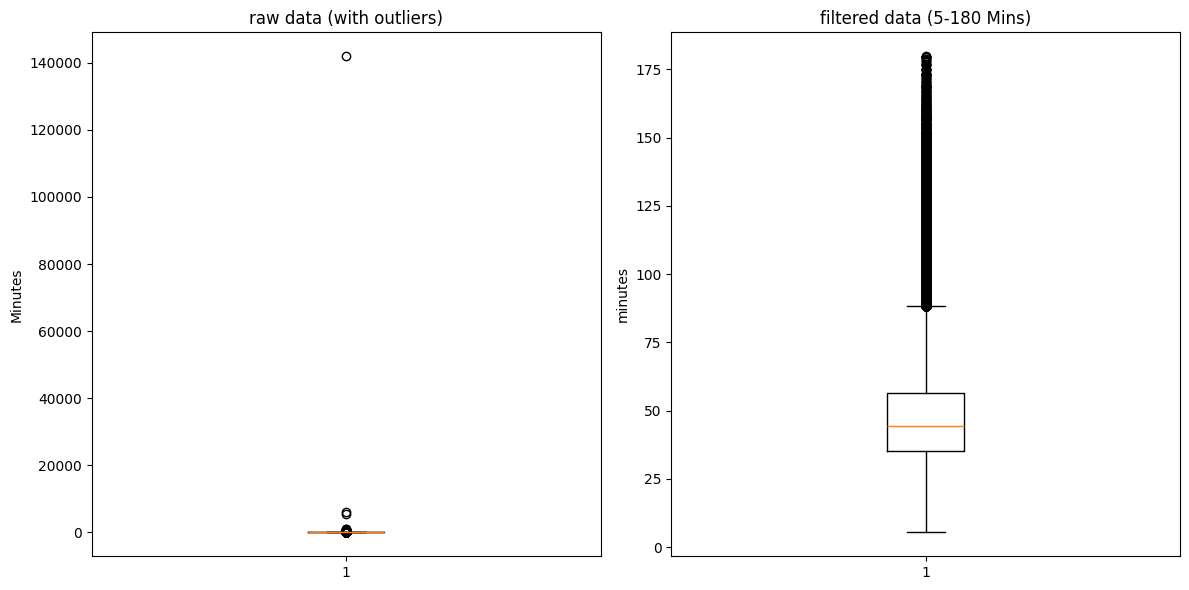

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 1. raw data (with outliers)
plt.subplot(1, 2, 1)
plt.boxplot(historical_data['actual_total_delivery_duration'].dropna() / 60)
plt.title('raw data (with outliers)')
plt.ylabel('Minutes')

# 2. filtered data (5-300 Mins)
plt.subplot(1, 2, 2)
# filter to 5-180 minutes to see the 'cleaned' version
filtered_duration = historical_data[
    (historical_data['actual_total_delivery_duration'] >= 300) & 
    (historical_data['actual_total_delivery_duration'] <= 10800)
]['actual_total_delivery_duration'] / 60

plt.boxplot(filtered_duration)
plt.title('filtered data (5-180 Mins)')
plt.ylabel('minutes')

plt.tight_layout()
plt.savefig('delivery_boxplots.png')
plt.show()

There is apparently one record in the data which has 140000 mins (~97.2 days) as the gap between created_at and actual_delivery_time. 
This is a pretty extreme outlier (almost certainly an error) and we have to cut records like this to have a reasonable result.
And after getting rid of the outliers, the data looks clean enough.

In [8]:
# keep only orders between 5 minutes (300s) and 3 hours (10800s)
# to get our models to avoid outliers

historical_data = historical_data[
    (historical_data['actual_total_delivery_duration'] >= 300) & 
    (historical_data['actual_total_delivery_duration'] <= 10800)
]

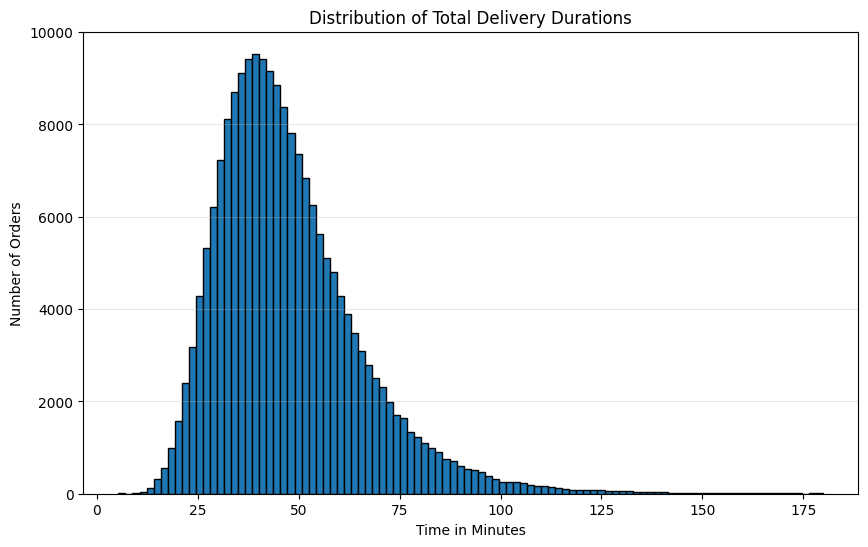

In [9]:
# visualize the distribution of the target variable (actual_total_delivery_duration) in minutes

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(historical_data['actual_total_delivery_duration'] / 60, bins=100, edgecolor='black')

# labels and title
plt.title('Distribution of Total Delivery Durations')
plt.xlabel('Time in Minutes')
plt.ylabel('Number of Orders')

plt.grid(axis='y', alpha=0.3)

plt.savefig('duration_histogram.png')
plt.show() 

We have most of our deliveries within 35-45 mins range, and there are some very long ones as well, at around 180 mins, which could happen (albeit extremely rarely) in real life.

Next, lets fill the missing values of some of the columns

Here I will fill the missing values in store_primary_category by using the most common category for that store observed in the data.

In [10]:
# get unique store ids
store_id_unique = historical_data["store_id"].unique().tolist()

# build dictionary >  store_id : most common category
store_id_and_category = {store_id: historical_data[historical_data.store_id == store_id].store_primary_category.mode() 
                         for store_id in store_id_unique}

# fill function
def fill(store_id):
    try:
        return store_id_and_category[store_id].values[0]
    except:
        return np.nan

# apply fill, overwrite the column
historical_data["store_primary_category"] = historical_data["store_id"].apply(fill)

For numeric nulls, since these are variables that are mostly related to regions, I will fill the missing values with median of the market id for the variable.

In [11]:
# numeric nulls : fill with median of that specific market id

numeric_cols = ["total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders"]

for col in numeric_cols:
    historical_data[col] = historical_data[col].fillna(
        historical_data.groupby('market_id')[col].transform('median')
    )
    
    # if a market_id has NO data, use the global median
    historical_data[col] = historical_data[col].fillna(historical_data[col].median())

# Feature Engineering

### Create some new variables that might be needed

New time features from given feature created_at:

hour_of_day ==> rush hour orders probably take longer

day_of_week ==> weekends likely busier

In [12]:
# convert to Pacific Time
historical_data['created_at_local'] = historical_data['created_at'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific')

# extract the local hour and day
historical_data['hour_of_day'] = historical_data['created_at_local'].dt.hour
historical_data['day_of_week'] = historical_data['created_at_local'].dt.dayofweek

Delivery drivers features

busy_ratio = total_busy_dashers / total_onshift_dashers 

==> what fraction are already busy



orders_per_dasher = total_outstanding_orders / total_onshift_dashers 

==> order load

In [13]:
# busy ratio
historical_data['busy_ratio'] = historical_data['total_busy_dashers'] / historical_data['total_onshift_dashers']

# load: orders per available dasher
historical_data['orders_per_dasher'] = historical_data['total_outstanding_orders'] / historical_data['total_onshift_dashers']

# if total_onshift_dashers is 0, fill them with 0 
historical_data.replace([np.inf, -np.inf], np.nan, inplace=True)
historical_data['busy_ratio'] = historical_data['busy_ratio'].fillna(0)
historical_data['orders_per_dasher'] = historical_data['orders_per_dasher'].fillna(0)

Order features

price_range = max_item_price - min_item_price

avg_item_price = subtotal / total_items


estimated_non_prep_duration = estimated_order_place_duration + estimated_store_to_consumer_driving_duration

==> this is a rough estimate, but it gives us a starting point for the non-prep time, which is what we ultimately want to predict

In [14]:
# order price range
historical_data['price_range'] = historical_data['max_item_price'] - historical_data['min_item_price']

# use total_items + 1 to avoid division by zero
historical_data['avg_item_price'] = historical_data['subtotal'] / (historical_data['total_items'] + 1)

historical_data['avg_item_price'] = historical_data['avg_item_price'].fillna(0)


# Non prep time
historical_data['estimated_non_prep_duration'] = (historical_data['estimated_order_place_duration'] + historical_data['estimated_store_to_consumer_driving_duration'])
# fill nulls in with the median 
historical_data['estimated_non_prep_duration'] = historical_data['estimated_non_prep_duration'].fillna(historical_data['estimated_non_prep_duration'].median())

### Now that we have some new features, we can visualize delivery time by timeframes, to better understand the context

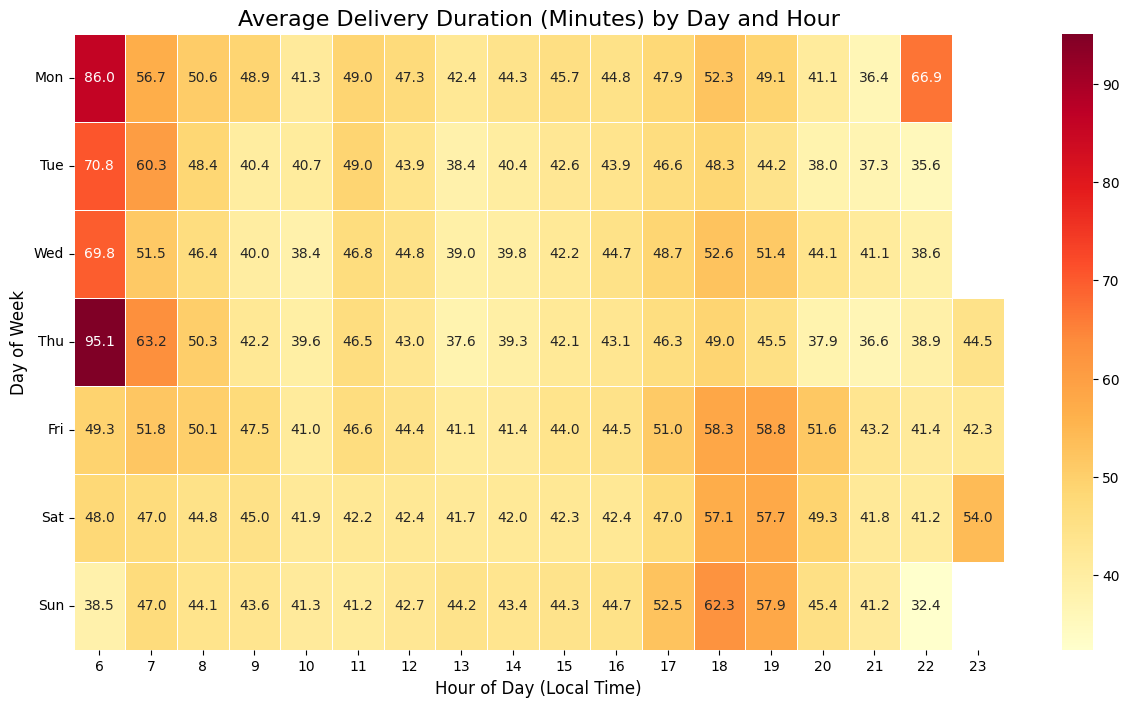

In [15]:
# visualize average delivery duration by day of week and hour of day using a heatmap

import seaborn as sns
# create a pivot table: Index = Days, Columns = Hours, Values = Average Duration

pivot_table = historical_data.pivot_table(
    index='day_of_week', 
    columns='hour_of_day', 
    values='actual_total_delivery_duration', 
    aggfunc='mean'
) / 60 # divide by 60 to show in minutes

plt.figure(figsize=(15, 8))
sns.heatmap(
    pivot_table, 
    annot=True,       
    fmt=".1f",        
    cmap="YlOrRd",    
    linewidths=.5
)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.yticks(ticks=[i + 0.5 for i in range(7)], labels=day_labels, rotation=0)

plt.title('Average Delivery Duration (Minutes) by Day and Hour', fontsize=16)
plt.xlabel('Hour of Day (Local Time)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.savefig('delivery_heatmap_duration.png')
plt.show()

We can observe that deliveries take longer around peak dinner and lunch hours, but the longest deliveries happen at early mornings where there are very few active drivers as well as fully operating stores. Could also be because the sample size is small. 

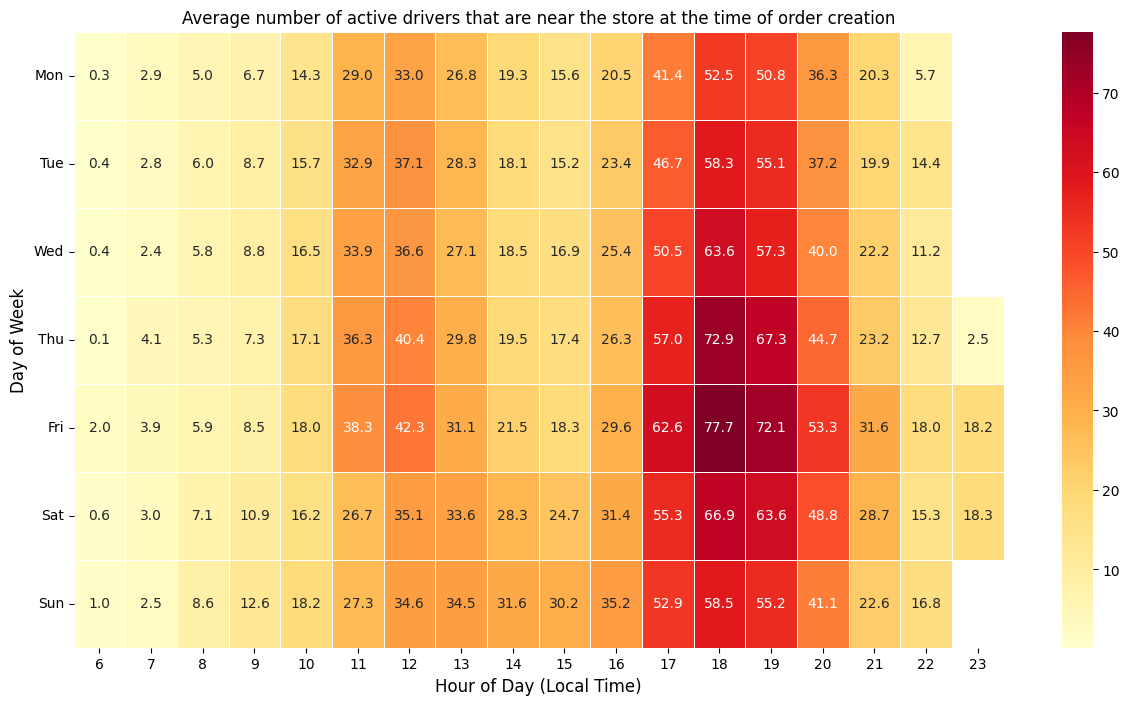

In [16]:
# total available drivers 
# who are within 10 miles of the store at the time of order creation

pivot_table = historical_data.pivot_table(
    index='day_of_week', 
    columns='hour_of_day', 
    values='total_onshift_dashers', 
    aggfunc='mean'
) 

plt.figure(figsize=(15, 8))
sns.heatmap(
    pivot_table, 
    annot=True,       
    fmt=".1f",        
    cmap="YlOrRd",    
    linewidths=.5
)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.yticks(ticks=[i + 0.5 for i in range(7)], labels=day_labels, rotation=0)

plt.title('Average number of active drivers that are near the store at the time of order creation', fontsize=12)
plt.xlabel('Hour of Day (Local Time)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.savefig('delivery_heatmap_drivers.png')
plt.show()


Even though the number of orders peak during lunch and dinner times, the number of active and nearby drivers peak as well and are sufficient to meet the demand, which is why we don't see a significant increase in delivery durations during those times.

# Encoding

One-hot encode market_id and order_protocol if there are small number of unique values

In [17]:
print(f"Unique Markets: {historical_data['market_id'].nunique()}")
print(f"Unique Protocols: {historical_data['order_protocol'].nunique()}")

Unique Markets: 6
Unique Protocols: 7


In [18]:
# we use prefix so we know which column is which
historical_data = pd.get_dummies(historical_data, columns=['market_id', 'order_protocol'], prefix=['m', 'p'])

Next, I will replace the category name with the average delivery time for that category (target encoding).

Instead of one-hot encoding, this may help prediction by encoding each category using its relationship to the target variable, while avoiding the high dimensionality caused by one-hot encoding.

To do this, let’s do a train/test split first, and use the average delivery time from the training data only for the encoding to prevent data leakage.

In [19]:
# sort by time
# model is trained on past data and tested on future data, which is more realistic

historical_data = historical_data.sort_values('created_at')

# simple 80/20 split
train_size = int(len(historical_data) * 0.8)
train_df = historical_data.iloc[:train_size].copy()
test_df = historical_data.iloc[train_size:].copy()

In [20]:
# calculate the average duration by category
category_means = train_df.groupby('store_primary_category')['actual_total_delivery_duration'].mean()

# map these averages back
train_df['category_en'] = train_df['store_primary_category'].map(category_means)
test_df['category_en'] = test_df['store_primary_category'].map(category_means)

# handle missing values
global_mean = train_df['actual_total_delivery_duration'].mean()
train_df['category_en'] = train_df['category_en'].fillna(global_mean)
test_df['category_en'] = test_df['category_en'].fillna(global_mean)

In [21]:
cols_to_drop = [
    'created_at', 'actual_delivery_time', 'created_at_local', 
    'store_primary_category',          # this is just a string now
    'store_id'                        # so many unique IDs
]

train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

In [22]:
train_df.isna().sum().sum() + test_df.isna().sum().sum()

np.int64(526)

And prepare the data for the training

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


#  split features (X) and target (y)
X_train = train_df.drop(columns=['actual_total_delivery_duration'])
y_train = train_df['actual_total_delivery_duration']

X_test = test_df.drop(columns=['actual_total_delivery_duration'])
y_test = test_df['actual_total_delivery_duration']

X_train.head()

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,...,m_5.0,m_6.0,p_1.0,p_2.0,p_3.0,p_4.0,p_5.0,p_6.0,p_7.0,category_en
43519,2,1058,2,219,799,2.0,1.0,1.0,251,463.0,...,False,False,False,False,False,True,False,False,False,2859.611622
148754,2,690,2,195,255,2.0,0.0,1.0,251,458.0,...,False,False,False,False,False,True,False,False,False,2699.272311
187014,3,1867,3,449,529,4.0,1.0,1.0,251,284.0,...,False,False,False,False,False,True,False,False,False,2656.975813
10265,3,955,3,245,345,3.0,2.0,2.0,251,377.0,...,False,False,False,False,False,True,False,False,False,2699.272311
188797,3,825,1,125,125,0.0,0.0,0.0,251,534.0,...,False,False,False,False,True,False,False,False,False,2643.075581


# Training the model

For simplicity and because we have a tabular data, lets use LightGBM as the predicition model.
Then we add simple MLP and Ridge to compare the results.

In [24]:
#  LightGBM

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,  # 31, 63, 127
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

# predict
y_pred = model.predict(X_test)

# evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae/60:.2f} minutes")
print(f"RMSE: {rmse/60:.2f} minutes")

# store predictions in a variable
lgb_preds = y_pred

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006544 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3082
[LightGBM] [Info] Number of data points in the train set: 157824, number of used features: 30
[LightGBM] [Info] Start training from score 2824.380392
MAE: 10.87 minutes
RMSE: 15.13 minutes


## So, final result for LightGBM is

MAE: 10.87 minutes

RMSE: 15.12 minutes


## Lets add simple MLP and Ridge models to try and compare the resutls

### Ridge

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# fill nans for the non-tree models
X_train_clean = X_train.fillna(X_train.median())
X_test_clean = X_test.fillna(X_train.median()) # use train median to avoid leakage

# scale the data (essential for MLP and Ridge)
# means that the features will have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

Ridge is a linear model that includes L2 regularization, which helps prevent overfitting by adding a penalty to the size of the coefficients. 
It's often more stable than ordinary least squares regression, especially when dealing with multicollinearity or when the number of features is large compared to the number of samples.

for beginners, what ridge regression does is that it adds a penalty to the size of the coefficients in the linear regression model.
linear regression in simple terms tries to find the best fit line that minimizes the sum of squared errors between the predicted values and the actual values.

In [26]:
# ridge regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)

In [27]:
# evaluate
ridge_mae = mean_absolute_error(y_test, ridge_preds)
print(f"Ridge Regression MAE: {ridge_mae/60:.2f} minutes")

Ridge Regression MAE: 11.67 minutes


### MLP on PyTorch

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# convert data to float32 tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# simple dataloader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)

class SimpleMLP(nn.Module):
    def __init__(self, input_size):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # single output (predicted seconds)
        )
        
    def forward(self, x):
        return self.net(x)

model_torch = SimpleMLP(X_train_t.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.002)

In [29]:
model_torch.train()
print("Training PyTorch MLP...")
for epoch in range(30): # 30 passes through the data
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_torch(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} - Loss: {total_loss/len(train_loader):.2f}")

Training PyTorch MLP...
Epoch 1 - Loss: 2336924.89
Epoch 2 - Loss: 920705.85
Epoch 3 - Loss: 877335.89
Epoch 4 - Loss: 862760.55
Epoch 5 - Loss: 850994.01
Epoch 6 - Loss: 843806.17
Epoch 7 - Loss: 839399.59
Epoch 8 - Loss: 834820.87
Epoch 9 - Loss: 831305.04
Epoch 10 - Loss: 828450.89
Epoch 11 - Loss: 825628.96
Epoch 12 - Loss: 823720.36
Epoch 13 - Loss: 821202.50
Epoch 14 - Loss: 819362.65
Epoch 15 - Loss: 817451.37
Epoch 16 - Loss: 816545.18
Epoch 17 - Loss: 815325.30
Epoch 18 - Loss: 814461.67
Epoch 19 - Loss: 813239.71
Epoch 20 - Loss: 812580.04
Epoch 21 - Loss: 811050.88
Epoch 22 - Loss: 810303.27
Epoch 23 - Loss: 809457.09
Epoch 24 - Loss: 808343.11
Epoch 25 - Loss: 807698.65
Epoch 26 - Loss: 806212.17
Epoch 27 - Loss: 805409.93
Epoch 28 - Loss: 804387.15
Epoch 29 - Loss: 803347.23
Epoch 30 - Loss: 802392.85


In [30]:
model_torch.eval()
with torch.no_grad():
    torch_preds = model_torch(X_test_t).numpy().flatten()

mlp_mae = mean_absolute_error(y_test, torch_preds)
print(f"PyTorch MLP MAE: {mlp_mae/60:.2f} minutes")

PyTorch MLP MAE: 11.46 minutes


In [31]:
# calculate MAE for all approaches (in minutes)
results = {
    'Model': ['LightGBM', 'Ridge Regression', 'PyTorch MLP'],
    'MAE (Minutes)': [
        mean_absolute_error(y_test, lgb_preds) / 60,
        mean_absolute_error(y_test, ridge_preds) / 60,
        mean_absolute_error(y_test, torch_preds) / 60
    ],
    'RMSE (Minutes)': [
    np.sqrt(mean_squared_error(y_test, lgb_preds)) / 60,
    np.sqrt(mean_squared_error(y_test, ridge_preds)) / 60,
    np.sqrt(mean_squared_error(y_test, torch_preds)) / 60,
    ]
}

df_results = pd.DataFrame(results).sort_values(by='MAE (Minutes)')

# 
print("--- Model Comparison ---")
print(df_results)

--- Model Comparison ---
              Model  MAE (Minutes)  RMSE (Minutes)
0          LightGBM      10.870175       15.129619
2       PyTorch MLP      11.463761       15.498749
1  Ridge Regression      11.668999       15.955224


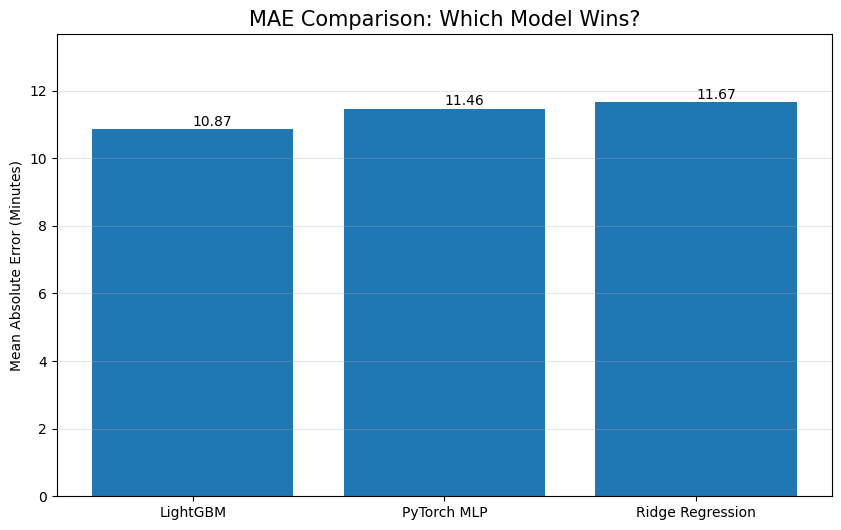

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(df_results['Model'], df_results['MAE (Minutes)'])

# add the actual numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2))

plt.title('MAE Comparison: Which Model Wins?', fontsize=15)
plt.ylabel('Mean Absolute Error (Minutes)')
plt.ylim(0, df_results['MAE (Minutes)'].max() + 2)
plt.grid(axis='y', alpha=0.3)

plt.savefig('model_comparison_mae.png')
plt.show()

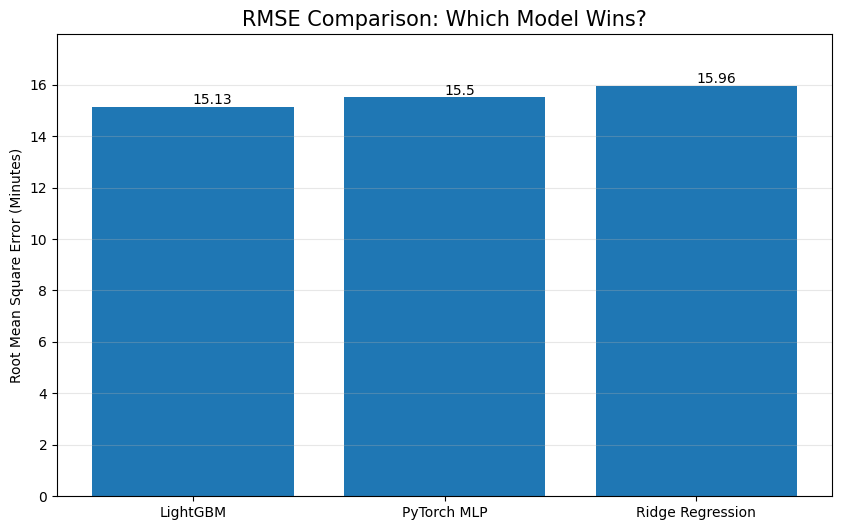

In [ ]:
# 2: RMSE
plt.figure(figsize=(10, 6))

bars = plt.bar(df_results['Model'], df_results['RMSE (Minutes)'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2))

plt.title('RMSE Comparison: Which Model Wins?', fontsize=15)
plt.ylabel('Root Mean Square Error (Minutes)')
plt.ylim(0, df_results['RMSE (Minutes)'].max() + 2)
plt.grid(axis='y', alpha=0.3)

plt.savefig('model_comparison_rmse.png')
plt.show()

**Looks like LightGBM was the winner!**

Next, lets see which features were the most important to LightGBM's prediction

In [34]:
# get feature importance
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(10))

                                         feature  importance
13                             orders_per_dasher        4891
9   estimated_store_to_consumer_driving_duration        4577
1                                       subtotal        4485
16                   estimated_non_prep_duration        4124
4                                 max_item_price        4035
12                                    busy_ratio        3872
30                                   category_en        3842
15                                avg_item_price        3757
3                                 min_item_price        3665
5                          total_onshift_dashers        3335


With a bar chart

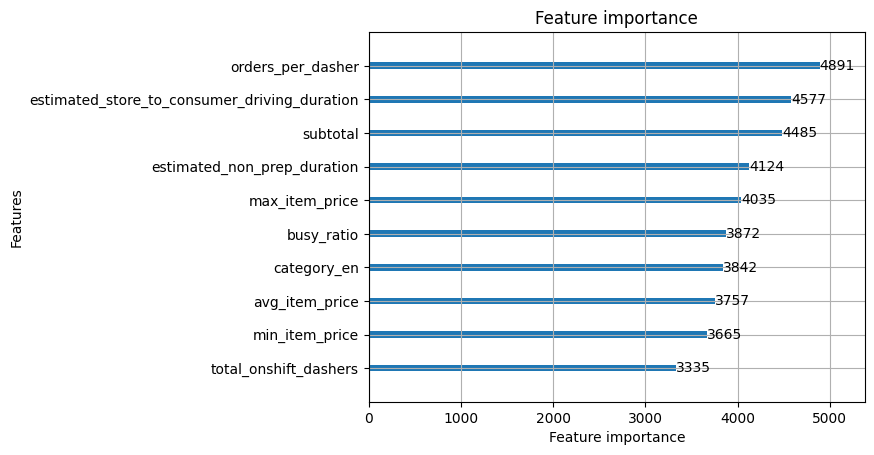

In [35]:
lgb.plot_importance(model, max_num_features=10)

plt.savefig('feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

Very interesting!